In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("thyroid_dataset.csv")
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [7]:
X = df.drop(columns=["Outlier_label"],axis=1)
Y = df["Outlier_label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=4.329461457233368/100,
    random_state=42
)

labels = model.fit_predict(X_scaled)

print(labels)

[ 1  1 -1 ...  1  1  1]


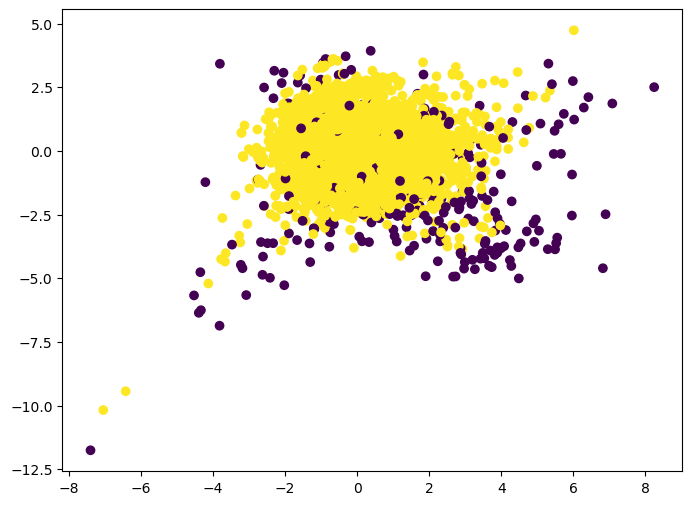

In [24]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)

In [25]:
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels==1)

print(n_normal,n_outliers)

print((n_outliers/n_normal)*100)

6616 300
4.534461910519952
